In [ ]:
!wget https://www.cse.wustl.edu/~jain/ehms/ftp/wustl-ehms-2020_with_attacks_categories.csv
!pip install xgboost numpy shap scikit-learn matplotlib
!pip install adversarial-robustness-toolbox

                 precision    recall  f1-score   support

         Benign       0.98      0.99      0.99      2827
Data Alteration       0.99      0.99      0.99       196
       Spoofing       0.92      0.72      0.81       240

       accuracy                           0.97      3263
      macro avg       0.96      0.90      0.93      3263
   weighted avg       0.97      0.97      0.97      3263



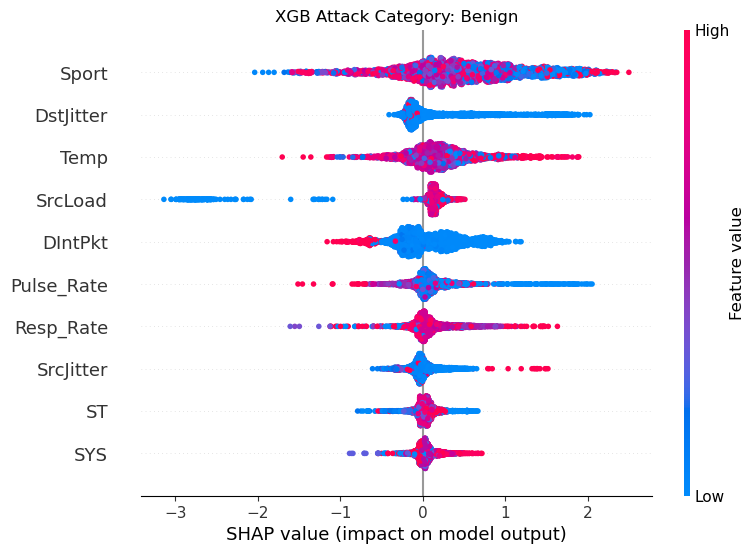

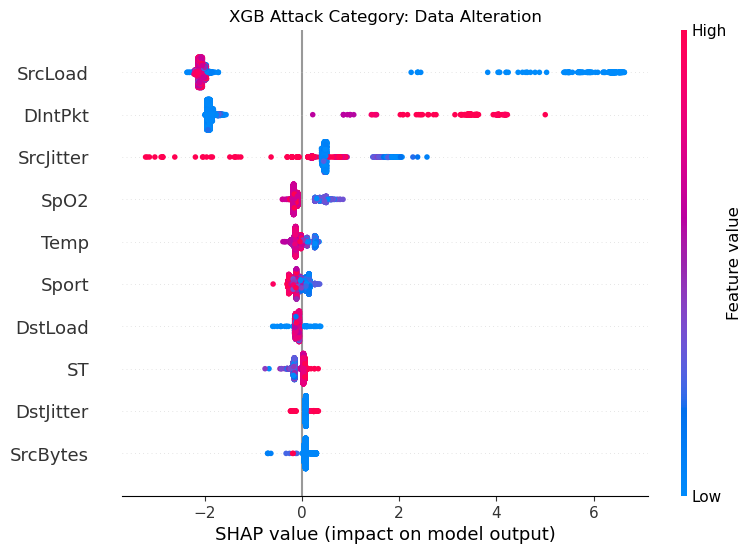

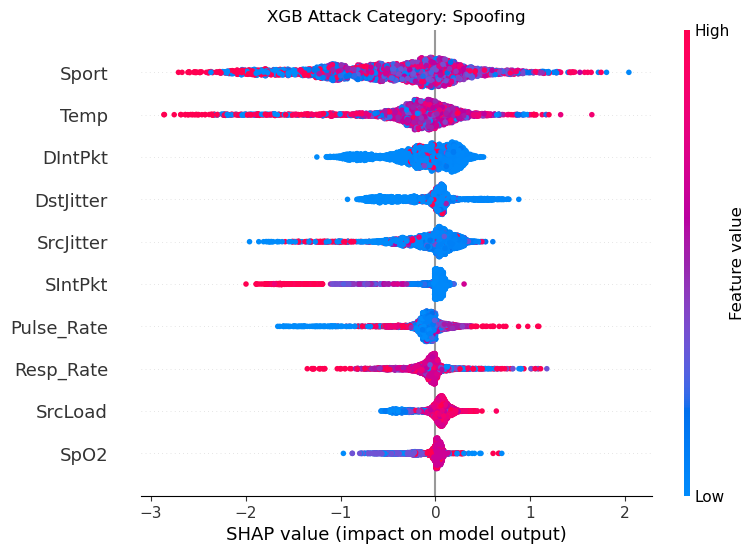

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import xgboost as xgb

# Load & preprocess
df = pd.read_csv('wustl-ehms-2020_with_attacks_categories.csv')
df['Attack Category'] = df['Attack Category'].replace('normal', 'Benign')
df.drop(columns=['SrcMac', 'Dir', 'Label', 'Flgs', 'Packet_num'], inplace=True)
df.drop(index=[10633, 7923, 8412], inplace=True)

# Label encoding
for col in ['Attack Category', 'DstMac', 'SrcAddr', 'DstAddr', 'Sport']:
    df[col] = LabelEncoder().fit_transform(df[col])

X, y = df.drop(columns='Attack Category'), df['Attack Category']

# Split & scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_trainN = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_testN = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# Train & evaluate
model = xgb.XGBClassifier(objective="binary:logistic")
model.fit(X_trainN, y_train)
print(classification_report(y_test, model.predict(X_testN), target_names=['Benign', 'Data Alteration', 'Spoofing']))

# SHAP analysis
explainer = shap.Explainer(model)
shap_vals = explainer.shap_values(X_testN)

# Summary plots for each class
class_names = ['Benign', 'Data Alteration', 'Spoofing']
for i, name in enumerate(class_names):
    shap.summary_plot(shap_vals[:, :, i], X_test, show=False, max_display=10)
    plt.title(f"XGB Attack Category: {name}")
    plt.show()

In [5]:
import numpy as np
import shap

# 1) Build a TreeExplainer and get an Explanation object
explainer = shap.TreeExplainer(model)
shap_exp = explainer(X_testN)                # shap_exp.values.shape == (n_samples, n_features, n_classes)

# 2) Pull out the raw NumPy array
shap_vals = shap_exp.values

# 3) Predictions & mask for Data Alteration FNs (class index=1)
y_pred    = model.predict(X_testN)
fn_mask   = (y_test.values == 1) & (y_pred != 1)

# 4) Slice for only the FN rows **and** only the Data Alteration class
#    shap_vals[:, :, 1] has shape (n_samples, n_features)
shap_fn    = shap_vals[:, :, 1][fn_mask]      # now shape = (n_FN, n_features)

# 5) Compute mean |SHAP| per feature
mean_abs  = np.mean(np.abs(shap_fn), axis=0)

# 6) Rank and select top‑3
feature_names = X_testN.columns
top_idx       = np.argsort(mean_abs)[-3:][::-1]
print("Top 3 features driving false negatives (Data Alteration):")
for i in top_idx:
    print(f"  • {feature_names[i]} (mean |SHAP| = {mean_abs[i]:.4f})")


Top 3 features driving false negatives (Data Alteration):
  • SrcLoad (mean |SHAP| = 4.4166)
  • DIntPkt (mean |SHAP| = 3.0092)
  • SrcJitter (mean |SHAP| = 2.4690)


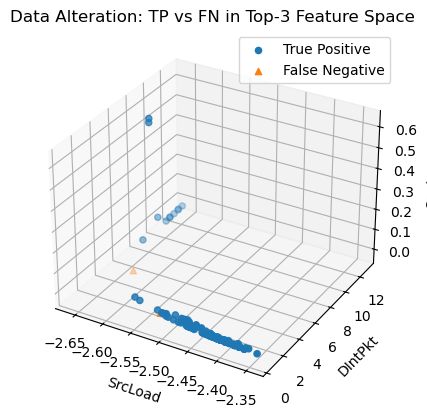

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

top_features = ['SrcLoad', 'DIntPkt', 'SrcJitter']

# —— ASSUMING YOU’VE ALREADY——
# • determined `top_features` as a list of your three feature names, e.g.
#     top_features = ['feat_A', 'feat_B', 'feat_C']
# • computed `y_pred = model.predict(X_testN)`
# • have your true labels `y_test`

# 1) Build masks for TP and FN in the Data Alteration class (index=1)
tp_mask = (y_test.values == 1) & (y_pred == 1)
fn_mask = (y_test.values == 1) & (y_pred != 1)

# 2) Extract the 3‑D coordinates for each set
coords_tp = X_testN.loc[tp_mask, top_features].values  # shape=(n_TP, 3)
coords_fn = X_testN.loc[fn_mask, top_features].values  # shape=(n_FN, 3)

# 3) Plot
fig = plt.figure()
ax  = fig.add_subplot(projection='3d')

# True Positives
ax.scatter(
    coords_tp[:, 0], coords_tp[:, 1], coords_tp[:, 2],
    marker='o', label='True Positive'
)

# False Negatives
ax.scatter(
    coords_fn[:, 0], coords_fn[:, 1], coords_fn[:, 2],
    marker='^', label='False Negative'
)

# 4) Labels & legend
ax.set_xlabel(top_features[0])
ax.set_ylabel(top_features[1])
ax.set_zlabel(top_features[2])
ax.set_title("Data Alteration: TP vs FN in Top‑3 Feature Space")
ax.legend()

plt.show()


Correlation matrix for top 3 features:
            SrcLoad   DIntPkt  SrcJitter
SrcLoad    1.000000 -0.340111  -0.069530
DIntPkt   -0.340111  1.000000   0.567878
SrcJitter -0.069530  0.567878   1.000000


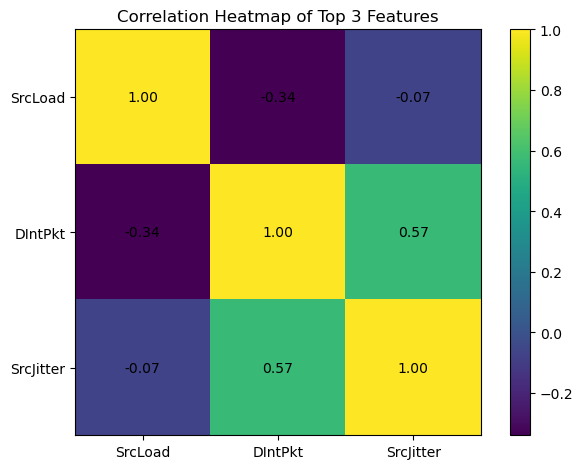

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# — Assumes you still have:
#   • X_testN (your scaled test DataFrame)
#   • top_features (a list of your three feature names, e.g. ['feat1','feat2','feat3'])

# 1) Compute the correlation matrix
corr_df = X_testN[top_features].corr()

print("Correlation matrix for top 3 features:")
print(corr_df)

# 2) Plot a heatmap with matplotlib
fig, ax = plt.subplots()
cax = ax.imshow(corr_df.values, aspect='equal')   # default colormap

# ticks and labels
ax.set_xticks(np.arange(len(top_features)))
ax.set_yticks(np.arange(len(top_features)))
ax.set_xticklabels(top_features)
ax.set_yticklabels(top_features)

# annotate with correlation coefficients
for i in range(len(top_features)):
    for j in range(len(top_features)):
        ax.text(j, i, f"{corr_df.iat[i,j]:.2f}", ha='center', va='center')

ax.set_title("Correlation Heatmap of Top 3 Features")
fig.colorbar(cax)
plt.tight_layout()
plt.show()


In [11]:
# Import the function to generate classification metrics
from sklearn.metrics import classification_report

# Define human‑readable class names for the three labels in your model
class_names = ['Benign', 'Data Alteration', 'Spoofing']

σ = X_testN['SrcLoad'].std()
δ = 0.5 * σ
X_adv = X_testN.copy()
is_data_alt = (y_test.values == 1)
X_adv.loc[is_data_alt, 'SrcLoad'] += δ
y_adv_pred = model.predict(X_adv)

print("=== Original on Test Set ===")
print(
    classification_report(
        y_test,
        model.predict(X_testN),       # model’s original predictions
        target_names=class_names
    )
)

# 8. Print out performance *after* perturbing SrcLoad on the Data Alteration samples:
print("\n=== After Perturbing SrcLoad by +0.5σ on Data Alteration Samples ===")
print(
    classification_report(
        y_test,
        y_adv_pred,                   # model’s predictions on the adversarial test set
        target_names=class_names
    )
)

=== Original on Test Set ===
                 precision    recall  f1-score   support

         Benign       0.98      0.99      0.99      2827
Data Alteration       0.99      0.99      0.99       196
       Spoofing       0.92      0.72      0.81       240

       accuracy                           0.97      3263
      macro avg       0.96      0.90      0.93      3263
   weighted avg       0.97      0.97      0.97      3263


=== After Perturbing SrcLoad by +0.5σ on Data Alteration Samples ===
                 precision    recall  f1-score   support

         Benign       0.91      0.99      0.95      2827
Data Alteration       0.00      0.00      0.00       196
       Spoofing       0.92      0.72      0.81       240

       accuracy                           0.91      3263
      macro avg       0.61      0.57      0.59      3263
   weighted avg       0.86      0.91      0.88      3263



In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# Your human-readable class names
class_names = ['Benign', 'Data Alteration', 'Spoofing']

# 1) Build adversarial set
σ = X_testN['SrcLoad'].std()
δ = 0.5 * σ
X_adv = X_testN.copy()
is_data_alt = (y_test.values == 1)
X_adv.loc[is_data_alt, 'SrcLoad'] += δ

# 2) Get predictions
y_pred_clean = model.predict(X_testN)
y_pred_adv   = model.predict(X_adv)

# 3) Original metrics
print("=== Original on Test Set ===")
print(classification_report(y_test, y_pred_clean, target_names=class_names))

cm_clean = confusion_matrix(y_test, y_pred_clean)
df_cm_clean = pd.DataFrame(cm_clean, index=class_names, columns=class_names)
print("Confusion Matrix (clean):")
print(df_cm_clean)

# 4) After perturbation
print("\n=== After Perturbing SrcLoad by +0.5σ on Data Alteration Samples ===")
print(classification_report(y_test, y_pred_adv, target_names=class_names))

cm_adv = confusion_matrix(y_test, y_pred_adv)
df_cm_adv = pd.DataFrame(cm_adv, index=class_names, columns=class_names)
print("Confusion Matrix (adversarial):")
print(df_cm_adv)


=== Original on Test Set ===
                 precision    recall  f1-score   support

         Benign       0.98      0.99      0.99      2827
Data Alteration       0.99      0.99      0.99       196
       Spoofing       0.92      0.72      0.81       240

       accuracy                           0.97      3263
      macro avg       0.96      0.90      0.93      3263
   weighted avg       0.97      0.97      0.97      3263

Confusion Matrix (clean):
                 Benign  Data Alteration  Spoofing
Benign             2810                1        16
Data Alteration       2              194         0
Spoofing             66                0       174

=== After Perturbing SrcLoad by +0.5σ on Data Alteration Samples ===
                 precision    recall  f1-score   support

         Benign       0.91      0.99      0.95      2827
Data Alteration       0.00      0.00      0.00       196
       Spoofing       0.92      0.72      0.81       240

       accuracy                        

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from art.utils import compute_success
from art.estimators.classification import XGBoostClassifier

# 1. Load and preprocess data
df = pd.read_csv('wustl-ehms-2020_with_attacks_categories.csv')
df['Attack Category'] = df['Attack Category'].replace('normal', 'Benign')
df.drop(columns=['SrcMac', 'Dir', 'Label', 'Flgs', 'Packet_num'], inplace=True)
df.drop(index=[10633, 7923, 8412], inplace=True)
for c in ['Attack Category', 'DstMac', 'SrcAddr', 'DstAddr', 'Sport']:
    df[c] = LabelEncoder().fit_transform(df[c])

X, y = df.drop(columns='Attack Category'), df['Attack Category']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_trainN = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_testN = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
num_classes = len(y.unique())

# 2. Train XGBoost
model = xgb.XGBClassifier(objective="binary:logistic", eval_metric='logloss')
model.fit(X_trainN, y_train)

# Original predictions and metrics
y_pred_orig = model.predict(X_testN)
orig_acc = accuracy_score(y_test, y_pred_orig)
print("=== Original Metrics ===")
print(f"Accuracy: {orig_acc:.2%}")
print(classification_report(
    y_test, y_pred_orig, target_names=['Benign','Data Alteration','Spoofing']
))

# 3. XAI-driven adversarial perturbation on 'SrcLoad'
sigma = X_testN['SrcLoad'].std()
delta = perturbation * sigma
X_adv_xai = X_testN.copy()
mask_da = (y_test.values == 1)
X_adv_xai.loc[mask_da, 'SrcLoad'] += delta

# Wrap model for ART
min_val, max_val = X_trainN.values.min(), X_trainN.values.max()
art_model = XGBoostClassifier(
    model=model,
    clip_values=(min_val, max_val),
    nb_classes=num_classes,
    nb_features=X_trainN.shape[1]
)

# Compute ART success rate for Data Alteration
y_clean_da = X_testN.to_numpy()[mask_da]
y_adv_da = X_adv_xai.to_numpy()[mask_da]
labels_da = y_test.to_numpy()[mask_da]
sr_data_alter = compute_success(
    classifier=art_model,
    x_clean=y_clean_da,
    labels=labels_da,
    x_adv=y_adv_da,
    targeted=False,
    batch_size=32
)
print(f"\nXAI-driven attack success on Data Alteration: {sr_data_alter*100:.2f}%")

# 4. Metrics on perturbed set
y_pred_adv = model.predict(X_adv_xai)
adversarial_acc = accuracy_score(y_test, y_pred_adv)
da_success = np.mean(y_pred_adv[mask_da] != y_test.to_numpy()[mask_da])
print("\n=== After XAI-driven Perturbation ===")
print(f"Accuracy: {adversarial_acc:.2%}")
print(f"Data Alteration misclassification rate: {da_success*100:.2f}%")
print(classification_report(
    y_test, y_pred_adv, target_names=['Benign','Data Alteration','Spoofing']
))

# 5. Confusion matrix plot
conf = confusion_matrix(y_test, y_pred_adv)
plt.figure(figsize=(6,5))
sns.heatmap(
    conf, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Benign','Data Alteration','Spoofing'],
    yticklabels=['Benign','Data Alteration','Spoofing']
)
plt.title('Confusion Matrix after XAI-driven Perturbation')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()



=== Original Metrics ===
Accuracy: 97.40%
                 precision    recall  f1-score   support

         Benign       0.98      0.99      0.99      2827
Data Alteration       0.99      0.99      0.99       196
       Spoofing       0.92      0.72      0.81       240

       accuracy                           0.97      3263
      macro avg       0.96      0.90      0.93      3263
   weighted avg       0.97      0.97      0.97      3263



NameError: name 'perturbation' is not defined

In [ ]:
## F1-score Curve Version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from art.utils import compute_success
from art.estimators.classification import XGBoostClassifier

# 1. Load and preprocess data
df = pd.read_csv('wustl-ehms-2020_with_attacks_categories.csv')
df['Attack Category'] = df['Attack Category'].replace('normal', 'Benign')
df.drop(columns=['SrcMac', 'Dir', 'Label', 'Flgs', 'Packet_num'], inplace=True)
df.drop(index=[10633, 7923, 8412], inplace=True)
for c in ['Attack Category', 'DstMac', 'SrcAddr', 'DstAddr', 'Sport']:
    df[c] = LabelEncoder().fit_transform(df[c])

X, y = df.drop(columns='Attack Category'), df['Attack Category']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_trainN = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_testN = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
num_classes = len(y.unique())

# 2. Train XGBoost
model = xgb.XGBClassifier(objective="binary:logistic", eval_metric='logloss')
model.fit(X_trainN, y_train)

# Original predictions and metrics
y_pred_orig = model.predict(X_testN)
orig_acc = accuracy_score(y_test, y_pred_orig)
print("=== Original Metrics ===")
print(f"Accuracy: {orig_acc:.2%}")
print(classification_report(
    y_test, y_pred_orig, target_names=['Benign','Data Alteration','Spoofing']
))

# 3. XAI-driven adversarial perturbation on 'SrcLoad'
perturbation = 0.25

sigma = X_testN['SrcLoad'].std()
delta = perturbation * sigma
X_adv_xai = X_testN.copy()
mask_da = (y_test.values == 1)
X_adv_xai.loc[mask_da, 'SrcLoad'] += delta

# 4. Metrics on perturbed set
y_pred_adv = model.predict(X_adv_xai)
adversarial_acc = accuracy_score(y_test, y_pred_adv)
da_success = np.mean(y_pred_adv[mask_da] != y_test.to_numpy()[mask_da])
print("\n=== After XAI-driven Perturbation ===")
print(f"Accuracy: {adversarial_acc:.2%}")
print(f"Data Alteration misclassification rate: {da_success*100:.2f}%")
print(classification_report(
    y_test, y_pred_adv, target_names=['Benign','Data Alteration','Spoofing']
))





In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, classification_report

#feature = 'SrcLoad'  # ← change as needed
feature = 'DIntPkt'  # ← change as needed

# Pre-computed quantities:
#   model      – your trained classifier
#   X_testN    – your normalized test set (pandas DataFrame)
#   y_test     – your true labels (pandas Series)

sigma = X_testN[feature].std()
perturbations = np.linspace(0.0, 0.34, 50)

f1_scores = []

for p in perturbations:
    delta = p * sigma
    X_adv = X_testN.copy()
    mask_da = (y_test.values == 1)
    X_adv.loc[mask_da, feature] += delta

    # Predict
    y_pred = model.predict(X_adv)

    # Compute and store macro F1
    f1 = f1_score(y_test, y_pred, average='macro')
    f1_scores.append(f1)

    # # Print full classification report
    # print(f"\n=== Perturbation: {p:.2f} × σ ({delta:.3f} added) ===")
    # print(classification_report(
    #     y_test, 
    #     y_pred, 
    #     target_names=['Benign', 'Data Alteration', 'Spoofing']
    # ))

# Finally, plot the F1‐score curve
plt.figure()
plt.plot(perturbations, f1_scores, marker='o')
plt.xlabel('Perturbation (fraction of σ)')
plt.ylabel('Macro F₁-Score')
plt.title(f'F₁-Score vs. Adversarial Perturbation on {feature}')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

#feature = 'SrcLoad'  # ← change as needed
feature = 'DIntPkt'  # ← change as needed

# Pre-computed quantities:
#   model      – your trained classifier
#   X_testN    – your normalized test set (pandas DataFrame)
#   y_test     – your true labels (pandas Series)

# 1. Compute the std of the chosen feature
sigma = X_testN[feature].std()

# 2. Define your perturbation fractions (0%–34% in 50 steps)
perturbations = np.linspace(0.0, 0.34, 50)

f1_scores = []

# 3. Loop over each perturbation level
for p in perturbations:
    delta = p * sigma
    X_adv = X_testN.copy()
    
    # Only perturb samples of class “Data Alteration” (label == 1)
    mask_da = (y_test.values == 1)
    X_adv.loc[mask_da, feature] += delta

    # Predict & compute macro F₁
    y_pred = model.predict(X_adv)
    f1 = f1_score(y_test, y_pred, average='macro')
    f1_scores.append(f1)


# 4. Plot the resulting curve
plt.figure()
plt.plot(perturbations, f1_scores,)
plt.xlabel('Perturbation (fraction of σ)')
plt.ylabel('Macro F₁-Score')
plt.title(f'F₁-Score vs. Adversarial Perturbation on {feature}')
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, classification_report

#feature = 'SrcLoad'  # ← change as needed
feature = 'DIntPkt'  # ← change as needed

# Pre-computed quantities:
#   model      – your trained classifier
#   X_testN    – your normalized test set (pandas DataFrame)
#   y_test     – your true labels (pandas Series)

sigma = X_testN[feature].std()
perturbations = np.linspace(-100, 100, 50)

f1_scores = []

for p in perturbations:
    delta = p * sigma
    X_adv = X_testN.copy()
    mask_da = (y_test.values == 1)
    X_adv.loc[mask_da, feature] += delta

    # Predict
    y_pred = model.predict(X_adv)

    # Compute and store macro F1
    f1 = f1_score(y_test, y_pred, average='macro')
    f1_scores.append(f1)

    # # Print full classification report
    # print(f"\n=== Perturbation: {p:.2f} × σ ({delta:.3f} added) ===")
    # print(classification_report(
    #     y_test, 
    #     y_pred, 
    #     target_names=['Benign', 'Data Alteration', 'Spoofing']
    # ))

# Finally, plot the F1‐score curve
plt.figure()
plt.plot(perturbations, f1_scores)
plt.xlabel('Perturbation (fraction of σ)')
plt.ylabel('Macro F₁-Score')
#plt.title(f'F₁-Score vs. Adversarial Perturbation on {feature}')
plt.grid(True)

# To save as PDF, uncomment one of these lines:
#plt.savefig('f1_vs_perturbation.pdf', format='pdf', bbox_inches='tight')
plt.savefig('f1_vs_perturbation_DA.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import xgboost as xgb

In [15]:
# Load & preprocess
df = pd.read_csv('wustl-ehms-2020_with_attacks_categories.csv')
df['Attack Category'] = df['Attack Category'].replace('normal', 'Benign')
df.drop(columns=['SrcMac', 'Dir', 'Label', 'Flgs', 'Packet_num'], inplace=True)
df.drop(index=[10633, 7923, 8412], inplace=True)

# Label encoding
for col in ['Attack Category', 'DstMac', 'SrcAddr', 'DstAddr', 'Sport']:
    df[col] = LabelEncoder().fit_transform(df[col])

X, y = df.drop(columns='Attack Category'), df['Attack Category']

# Split & scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_trainN = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_testN = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# Train & evaluate
model = xgb.XGBClassifier(objective="binary:logistic")
model.fit(X_trainN, y_train)
print(classification_report(y_test, model.predict(X_testN), target_names=['Benign', 'Data Alteration', 'Spoofing']))


from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# Your human-readable class names
class_names = ['Benign', 'Data Alteration', 'Spoofing']

# 1) Build adversarial set
σ = X_testN['SrcLoad'].std()
δ = 0.5 * σ
X_adv = X_testN.copy()
is_data_alt = (y_test.values == 1)
X_adv.loc[is_data_alt, 'SrcLoad'] += δ

# 2) Get predictions
y_pred_clean = model.predict(X_testN)
y_pred_adv   = model.predict(X_adv)

# 3) Original metrics
print("=== Original on Test Set ===")
print(classification_report(y_test, y_pred_clean, target_names=class_names))

cm_clean = confusion_matrix(y_test, y_pred_clean)
df_cm_clean = pd.DataFrame(cm_clean, index=class_names, columns=class_names)
print("Confusion Matrix (clean):")
print(df_cm_clean)

# 4) After perturbation
print("\n=== After Perturbing SrcLoad by +0.5σ on Data Alteration Samples ===")
print(classification_report(y_test, y_pred_adv, target_names=class_names))

cm_adv = confusion_matrix(y_test, y_pred_adv)
df_cm_adv = pd.DataFrame(cm_adv, index=class_names, columns=class_names)
print("Confusion Matrix (adversarial):")
print(df_cm_adv)

                 precision    recall  f1-score   support

         Benign       0.98      0.99      0.99      2827
Data Alteration       0.99      0.99      0.99       196
       Spoofing       0.92      0.72      0.81       240

       accuracy                           0.97      3263
      macro avg       0.96      0.90      0.93      3263
   weighted avg       0.97      0.97      0.97      3263

=== Original on Test Set ===
                 precision    recall  f1-score   support

         Benign       0.98      0.99      0.99      2827
Data Alteration       0.99      0.99      0.99       196
       Spoofing       0.92      0.72      0.81       240

       accuracy                           0.97      3263
      macro avg       0.96      0.90      0.93      3263
   weighted avg       0.97      0.97      0.97      3263

Confusion Matrix (clean):
                 Benign  Data Alteration  Spoofing
Benign             2810                1        16
Data Alteration       2              19